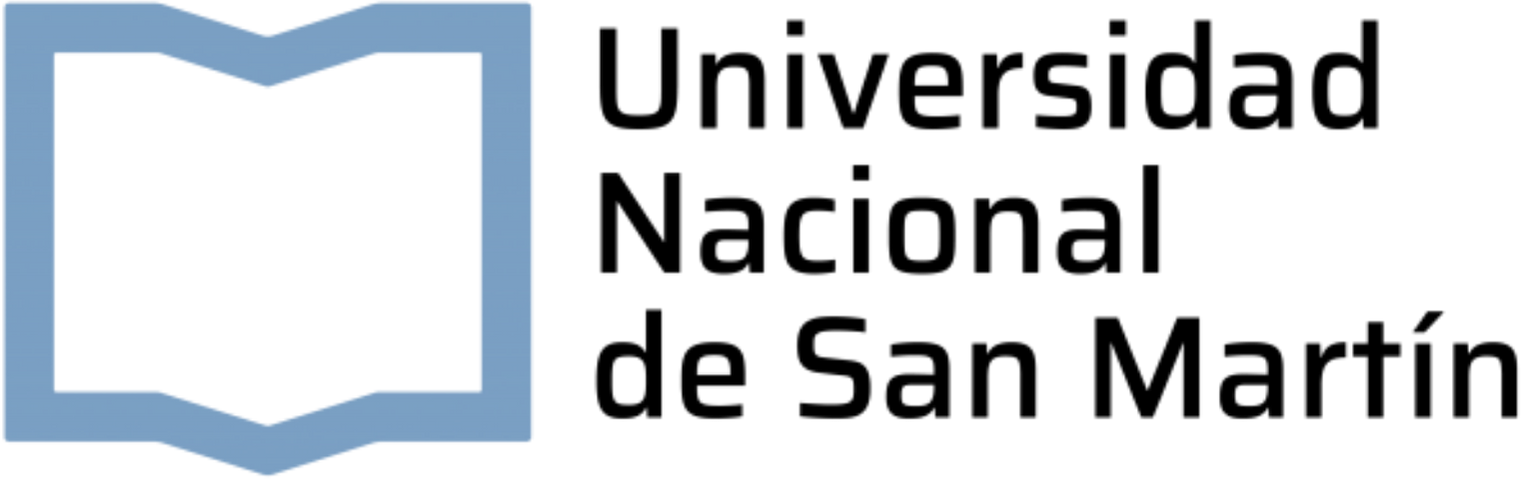

# TS4: Primeras nociones de estimación espectral
# Cristóbal Contador

## Introducción

En esta práctica se tiene como objetivo analizar y comparar el comportamiento de distintas funciones de ventaneo (Rectangular, Flat-top, Blackman-Harris y Hann) al estimar la amplitud ($\hat{a}_1$) y la frecuencia ($\hat{\Omega}_1$) de una señal senoidal con ruido gaussiano. La idea es ver cómo la elección de la ventana influye en la precisión de los estimadores cuando la frecuencia de la señal no coincide exactamente con la grilla de la DFT.
En este trabajo nos enfocamos en analizar cómo se combinan la desintonía en frecuencia y el ruido mediante dos parámetros principales:

* Desintonía en frecuencia ($f_r \sim U(-2,2)$ bines): la frecuencia de la senoidal varía aleatoriamente alrededor de la frecuencia que usamos de referencia $\Omega_0 = \pi/2$, simulando el caso en que la frecuencia de la señal no coincide exactamente con un bin de la DFT.
* Ruido gaussiano a dos niveles de SNR (3 dB y 10 dB): para analizar cómo cambia la precisión de las estimaciones cuando aumenta la relación señal a ruido.

Para estudiar estos efectos se utiliza una simulación de estilo Monte Carlo, realizando múltiples experimentos independientes y analizando estadísticamente los resultados obtenidos con cada ventana.
A lo largo de esta simulación se analizarán estos efectos mediante estos tres analisis:

* Histogramas de amplitud y frecuencia, para observar la distribución de las estimaciones ($\hat{a}_1$ y $\hat{\Omega}_1$) y comparar la dispersión obtenida con cada ventana.
* Cálculo del sesgo y la varianza, para cuantificar qué tan cerca se encuentran las estimaciones de sus valores teóricos y cuánto varían entre las distintas realizaciones.
* Comparación entre SNR de 3 dB y 10 dB, para analizar cómo el aumento de la relación señal a ruido afecta la dispersión de las estimaciones y el comportamiento de cada ventana.

## **1)** Visualizar, para cada SNR, un histograma con las 4 ventanas juntas. Realice un análisis cualitativo.

Primero haremos todos nuestros imports asi como los parametros fijos de la experimentación:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.close('all')

fs = 1000  # frecuencia de sampleo
N = 1000  # muestras
M = 200
df = fs / N

a0 = np.sqrt(2)  # simplemente mi amplitud maxima

psen = a0**2 / 2

fr = np.random.uniform(-2, 2, M)

omega = np.pi / 2

omega1 = omega + (2 * np.pi / N) * fr

omega1mat = omega1.reshape(M, 1)

nn = np.arange(N)


Ahora crearemos nuestra función senoidal y la ventanearemos con los cuatro tipos de ventana que decidimos utilizar.


In [2]:
#%%

snr = 3

desv = np.sqrt(psen / (10 ** (snr / 10)))

na = np.random.normal(0, desv, (N, M))

def mi_funcion_sen():
    nn = np.arange(N)
    nnmat = nn.reshape(N, 1)

    xx = (
        a0 * np.sin(nnmat * (np.transpose(omega1mat))) + na)

    return xx


xx = mi_funcion_sen()


#%% Rectangular

vent1 = np.ones((N, 1))

xx_vent1 = xx * vent1

fxx = np.transpose(
    np.fft.fft(np.transpose(xx_vent1))
)

faxx = np.abs(fxx[:N//2, :]) / np.sum(vent1)

a1 = faxx[N//4, :]

k_max1 = np.argmax(faxx, axis=0)

w_hat1 = k_max1 * (2 * np.pi / N)


#%% Flat-top

vent2 = signal.windows.flattop(M=N).reshape(N, 1)

xx_vent2 = xx * vent2

fxx_vent2 = np.transpose(
    np.fft.fft(np.transpose(xx_vent2))
)

faxx_vent2 = np.abs(fxx_vent2[:N//2, :]) / np.sum(vent2)

a1_vent2 = faxx_vent2[N//4, :]

k_max2 = np.argmax(faxx_vent2, axis=0)

w_hat2 = k_max2 * (2 * np.pi / N)


#%% Blackman-Harris

vent3 = signal.windows.blackmanharris(M=N).reshape(N, 1)

xx_vent3 = xx * vent3

fxx_vent3 = np.transpose(
    np.fft.fft(np.transpose(xx_vent3))
)

faxx_vent3 = np.abs(fxx_vent3[:N//2]) / np.sum(vent3)

a1_vent3 = faxx_vent3[N//4, :]

k_max3 = np.argmax(faxx_vent3, axis=0)

w_hat3 = k_max3 * (2 * np.pi / N)


#%% Hann

vent4 = signal.windows.hann(M=N).reshape(N, 1)

xx_vent4 = xx * vent4

fxx_vent4 = np.transpose(
    np.fft.fft(np.transpose(xx_vent4))
)

faxx_vent4 = np.abs(fxx_vent4[:N//2]) / np.sum(vent4)

a1_vent4 = faxx_vent4[N//4, :]

k_max4 = np.argmax(faxx_vent4, axis=0)

w_hat4 = k_max4 * (2 * np.pi / N)

Y, por último, imprimiremos los histogramas de los estimadores de amplitud y frecuencia para $ SNR = 3db $


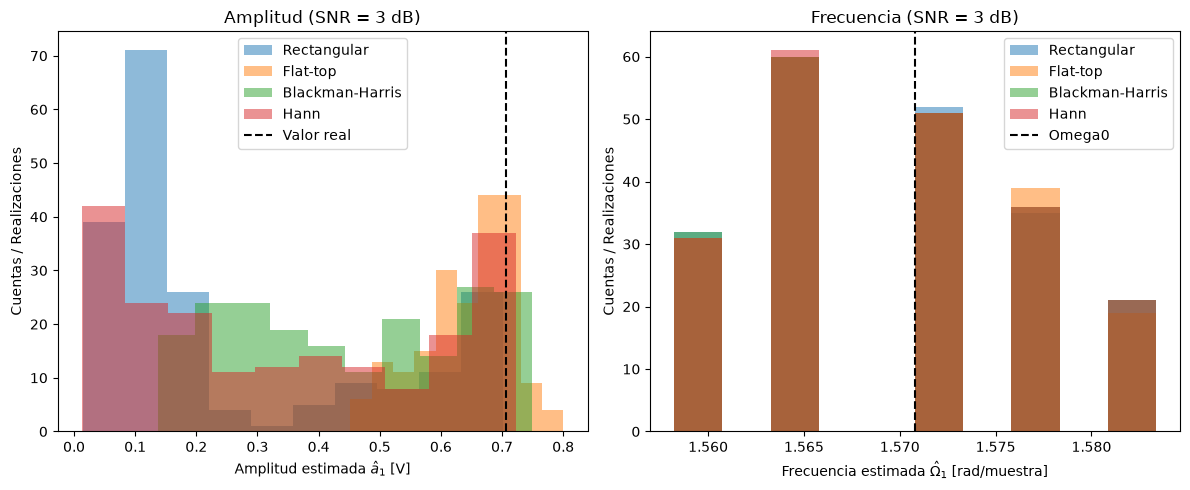

In [3]:
#%% Histogramas (SNR = 3 dB)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histograma de Amplitud
ax[0].hist(a1, alpha=0.5, label='Rectangular')
ax[0].hist(a1_vent2, alpha=0.5, label='Flat-top')
ax[0].hist(a1_vent3, alpha=0.5, label='Blackman-Harris')
ax[0].hist(a1_vent4, alpha=0.5, label='Hann')

ax[0].axvline(
    a0/2,
    color='k',
    linestyle='--',
    label='Valor real'
)

ax[0].set_title('Amplitud (SNR = 3 dB)')
ax[0].set_xlabel('Amplitud estimada $\hat{a}_1$ [V]')
ax[0].set_ylabel('Cuentas / Realizaciones')
ax[0].legend()


# Histograma de Frecuencia
ax[1].hist(w_hat1, alpha=0.5, label='Rectangular')
ax[1].hist(w_hat2, alpha=0.5, label='Flat-top')
ax[1].hist(w_hat3, alpha=0.5, label='Blackman-Harris')
ax[1].hist(w_hat4, alpha=0.5, label='Hann')

ax[1].axvline(
    omega,
    color='k',
    linestyle='--',
    label='Omega0'
)

ax[1].set_title('Frecuencia (SNR = 3 dB)')
ax[1].set_xlabel('Frecuencia estimada $\hat{\Omega}_1$ [rad/muestra]')
ax[1].set_ylabel('Cuentas / Realizaciones')
ax[1].legend()

plt.tight_layout()
plt.show()

**Figura 1.** *Distribución de la amplitud estimada ($\hat{a}_1$) y la frecuencia estimada ($\hat{\Omega}_1$) para SNR = 3 dB. La línea punteada en el histograma de amplitud representa el valor teórico $\sqrt{2}/2 $ V, mientras que en el histograma de frecuencia representa la frecuencia nominal $\Omega_0 = \pi/2$ rad/muestra.*



En la **Figura 1** podemos observar cómo se distribuyen las estimaciones de amplitud y frecuencia para un nivel de ruido de **SNR = 3 dB**.

En el **histograma de amplitud** (izquierda), podemos ver que las distintas ventanas producen resultados diferentes. La ventana **Flat-top** presenta una distribución centrada muy cerca del valor teórico $\sqrt{2}/2 \approx 0.7071$ V, por lo que presenta un sesgo cercano a cero. Por otro lado, las ventanas **Rectangular**, **Blackman-Harris** y **Hann** presentan un sesgo mayor pero con signo negativo, dando valores menores debido a la pérdida de amplitud producida por la desintonía de la frecuencia respecto de los bines de la DFT (*scalloping loss*). La mayor dispersión de los histogramas se relaciona con una mayor varianza debido al ruido agregado a la señal.

En el **histograma de frecuencia** (derecha), las estimaciones $\hat{\Omega}_1$ se encuentran alrededor de la frecuencia de referencia $\Omega_0 = \pi/2$ rad/muestra. Como la estimación se realiza buscando el bin de mayor amplitud, los valores obtenidos son discretos y pueden caer en distintos bines cercanos debido a la resolución de la DFT, la desintonía aleatoria y el ruido. En este caso, las cuatro ventanas presentan un comportamiento similar, con un sesgo cercano a cero.



Ahora haremos el caso con $ SNR = 10db $

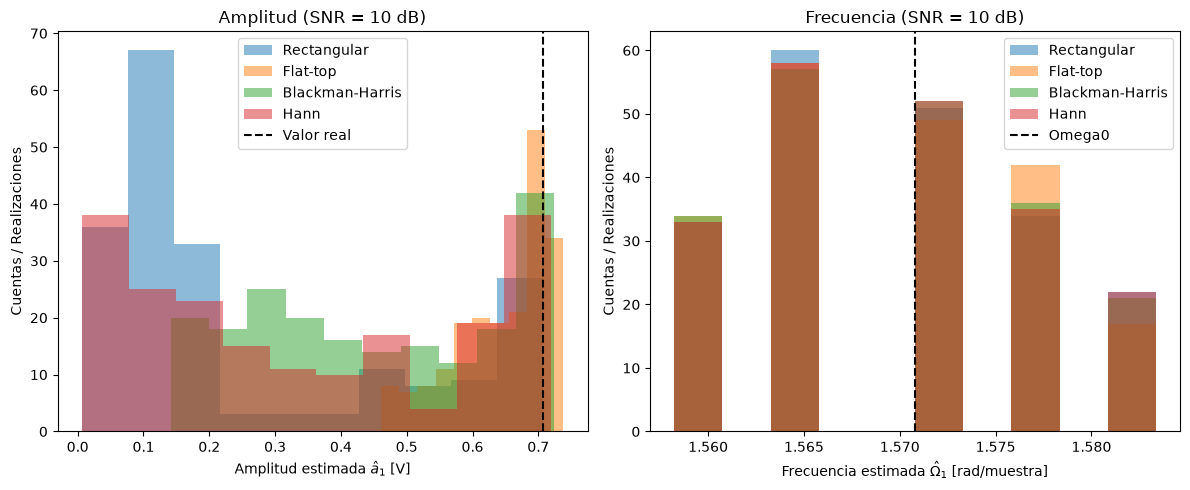

In [4]:
#%% snr 10

snr_2 = 10

desv_2 = np.sqrt(psen / (10 ** (snr_2 / 10)))

na_2 = np.random.normal(0, desv_2, (N, M))


def mi_funcion_sen_2():
    nnmat = nn.reshape(N, 1)

    xx_2 = (
        a0 * np.sin(nnmat * (np.transpose(omega1mat)))+ na_2)

    return xx_2


xx_2 = mi_funcion_sen_2()


#%% Rectangular (10 dB)

xx_vent1_2 = xx_2 * vent1

fxx_2 = np.transpose(
    np.fft.fft(np.transpose(xx_vent1_2))
)

faxx_2 = np.abs(fxx_2[:N//2, :]) / np.sum(vent1)

a1_2 = faxx_2[N//4, :]

k_max1_2 = np.argmax(faxx_2, axis=0)

w_hat1_2 = k_max1_2 * (2 * np.pi / N)


#%% Flat-top (10 dB)

xx_vent2_2 = xx_2 * vent2

fxx_vent2_2 = np.transpose(
    np.fft.fft(np.transpose(xx_vent2_2))
)

faxx_vent2_2 = np.abs(fxx_vent2_2[:N//2, :]) / np.sum(vent2)

a1_vent2_2 = faxx_vent2_2[N//4, :]

k_max2_2 = np.argmax(faxx_vent2_2, axis=0)

w_hat2_2 = k_max2_2 * (2 * np.pi / N)


#%% Blackman-Harris (10 dB)

xx_vent3_2 = xx_2 * vent3

fxx_vent3_2 = np.transpose(
    np.fft.fft(np.transpose(xx_vent3_2))
)

faxx_vent3_2 = np.abs(fxx_vent3_2[:N//2, :]) / np.sum(vent3)

a1_vent3_2 = faxx_vent3_2[N//4, :]

k_max3_2 = np.argmax(faxx_vent3_2, axis=0)

w_hat3_2 = k_max3_2 * (2 * np.pi / N)


#%% Hann (10 dB)

xx_vent4_2 = xx_2 * vent4

fxx_vent4_2 = np.transpose(
    np.fft.fft(np.transpose(xx_vent4_2))
)

faxx_vent4_2 = np.abs(fxx_vent4_2[:N//2, :]) / np.sum(vent4)

a1_vent4_2 = faxx_vent4_2[N//4, :]

k_max4_2 = np.argmax(faxx_vent4_2, axis=0)

w_hat4_2 = k_max4_2 * (2 * np.pi / N)


#%% Histogramas (SNR = 10 dB)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))


# Histograma de Amplitud

ax[0].hist(a1_2, alpha=0.5, label='Rectangular')
ax[0].hist(a1_vent2_2, alpha=0.5, label='Flat-top')
ax[0].hist(a1_vent3_2, alpha=0.5, label='Blackman-Harris')
ax[0].hist(a1_vent4_2, alpha=0.5, label='Hann')

ax[0].axvline(
    a0/2,
    color='k',
    linestyle='--',
    label='Valor real'
)

ax[0].set_title('Amplitud (SNR = 10 dB)')
ax[0].set_xlabel('Amplitud estimada $\hat{a}_1$ [V]')
ax[0].set_ylabel('Cuentas / Realizaciones')
ax[0].legend()


# Histograma de Frecuencia

ax[1].hist(w_hat1_2, alpha=0.5, label='Rectangular')
ax[1].hist(w_hat2_2, alpha=0.5, label='Flat-top')
ax[1].hist(w_hat3_2, alpha=0.5, label='Blackman-Harris')
ax[1].hist(w_hat4_2, alpha=0.5, label='Hann')

ax[1].axvline(
    omega,
    color='k',
    linestyle='--',
    label='Omega0'
)

ax[1].set_title('Frecuencia (SNR = 10 dB)')
ax[1].set_xlabel('Frecuencia estimada $\hat{\Omega}_1$ [rad/muestra]')
ax[1].set_ylabel('Cuentas / Realizaciones')
ax[1].legend()

plt.tight_layout()
plt.show()

**Figura 2.** *Distribución de la amplitud estimada ($\hat{a}_1$) y la frecuencia estimada ($\hat{\Omega}_1$) para SNR = 10 dB. La línea punteada en el histograma de amplitud representa el valor teórico $\sqrt{2}/2 $ V, mientras que en el histograma de frecuencia representa la frecuencia nominal $\Omega_0 = \pi/2$ rad/muestra.*


En la **Figura 2** podemos observar la distribución de las estimaciones para un nivel de ruido menor, con **SNR = 10 dB**.

En el **histograma de amplitud** (izquierda), podemos ver que las distribuciones presentan una menor varianza que en el caso de SNR = 3 dB, debido a que ahora tenemos una mayor relación señal a ruido. La ventana **Flat-top** continúa presentando una distribución centrada muy cerca del valor teórico $\sqrt{2}/2 \approx 0.7071$ V, por lo que mantiene un sesgo cercano a cero. Por otro lado, las ventanas **Rectangular**, **Blackman-Harris** y **Hann** siguen presentando un sesgo mayor debido a la pérdida de amplitud producida por la desintonía respecto de los bines de la DFT (*Scalloping loss*). Por lo tanto, al aumentar la SNR disminuye la varianza de las estimaciones, mientras que el sesgo se mantiene aproximadamente igual.

En el **histograma de frecuencia** (derecha), las estimaciones $\hat{\Omega}_1$ siguen concentrándose alrededor de la frecuencia de referencia $\Omega_0 = \pi/2$ rad/muestra. Al igual que en el caso anterior, los valores se distribuyen en distintos bines debido a la resolución de la DFT y a la desintonía aleatoria. Las cuatro ventanas presentan un comportamiento similar, con un sesgo cercano a cero respecto de la frecuencia de referencia.



## **2)** Realizar una tabla por cada SNR que describa el sesgo y la varianza de cada estimador para cada ventana analizada, como las que se muestran a continuación.

Ahora haremos los calculos de sesgo y varianza para las diferentes ventanas.

In [5]:
import pandas as pd

#snr 3
esperanza = np.mean(a1)
sesgo = esperanza - a0/2
varianza = np.var(a1)

esperanza_vent2 = np.mean(a1_vent2)
sesgo_vent2 = esperanza_vent2 - a0/2
varianza_vent2 = np.var(a1_vent2)

esperanza_vent3 = np.mean(a1_vent3)
sesgo_vent3 = esperanza_vent3 - a0/2
varianza_vent3 = np.var(a1_vent3)

esperanza_vent4 = np.mean(a1_vent4)
sesgo_vent4 = esperanza_vent4 - a0/2
varianza_vent4 = np.var(a1_vent4)


sesgo_w1 = np.mean(w_hat1 - omega1)
varianza_w1 = np.var(w_hat1)

sesgo_w2 = np.mean(w_hat2 - omega1)
varianza_w2 = np.var(w_hat2)

sesgo_w3 = np.mean(w_hat3 - omega1)
varianza_w3 = np.var(w_hat3)

sesgo_w4 = np.mean(w_hat4 - omega1)
varianza_w4 = np.var(w_hat4)


#snr 10
esperanza_2 = np.mean(a1_2)
sesgo_2 = esperanza_2 - a0/2
varianza_2 = np.var(a1_2)

esperanza_vent2_2 = np.mean(a1_vent2_2)
sesgo_vent2_2 = esperanza_vent2_2 - a0/2
varianza_vent2_2 = np.var(a1_vent2_2)

esperanza_vent3_2 = np.mean(a1_vent3_2)
sesgo_vent3_2 = esperanza_vent3_2 - a0/2
varianza_vent3_2 = np.var(a1_vent3_2)

esperanza_vent4_2 = np.mean(a1_vent4_2)
sesgo_vent4_2 = esperanza_vent4_2 - a0/2
varianza_vent4_2 = np.var(a1_vent4_2)


sesgo_w1_2 = np.mean(w_hat1_2 - omega1)
varianza_w1_2 = np.var(w_hat1_2)

sesgo_w2_2 = np.mean(w_hat2_2 - omega1)
varianza_w2_2 = np.var(w_hat2_2)

sesgo_w3_2 = np.mean(w_hat3_2 - omega1)
varianza_w3_2 = np.var(w_hat3_2)

sesgo_w4_2 = np.mean(w_hat4_2 - omega1)
varianza_w4_2 = np.var(w_hat4_2)



Y ahora imprimiremos la primera tabla, la de amplitudes:

In [6]:
#%% TABLAS DE AMPLITUD

data_amp_3 = {
    'Ventana': ['Rectangular', 'Flat-top', 'Blackman-Harris', 'Hann'],
    'Sesgo': [sesgo, sesgo_vent2, sesgo_vent3, sesgo_vent4],
    'Varianza': [varianza, varianza_vent2, varianza_vent3, varianza_vent4]
}

data_amp_10 = {
    'Ventana': ['Rectangular', 'Flat-top', 'Blackman-Harris', 'Hann'],
    'Sesgo': [sesgo_2, sesgo_vent2_2, sesgo_vent3_2, sesgo_vent4_2],
    'Varianza': [varianza_2, varianza_vent2_2, varianza_vent3_2, varianza_vent4_2]
}

print("=== TABLAS DE AMPLITUD ===")

print("\n--- SNR = 3 dB ---")
print(pd.DataFrame(data_amp_3).to_string(index=False))

print("\n--- SNR = 10 dB ---")
print(pd.DataFrame(data_amp_10).to_string(index=False))

=== TABLAS DE AMPLITUD ===

--- SNR = 3 dB ---
        Ventana     Sesgo  Varianza
    Rectangular -0.453491  0.049092
       Flat-top -0.063257  0.005745
Blackman-Harris -0.259015  0.033914
           Hann -0.368038  0.058138

--- SNR = 10 dB ---
        Ventana     Sesgo  Varianza
    Rectangular -0.454605  0.051153
       Flat-top -0.062913  0.005104
Blackman-Harris -0.258050  0.033977
           Hann -0.367850  0.059195


**Tabla 1.** *Sesgo y varianza de las estimaciones de amplitud ($\hat{a}_1$) para SNR = 3 dB y SNR = 10 dB, utilizando las ventanas Rectangular, Flat-top, Blackman-Harris y Hann. El valor teórico de referencia es $a_0/2 = \sqrt{2}/2 \approx 0.7071$ V.*


En la **Tabla 1** podemos comparar numéricamente el comportamiento de las distintas ventanas para la estimación de amplitud ($\hat{a}_1$), teniendo en cuenta el **sesgo** y la **varianza**.

En cuanto al **sesgo**, la ventana **Flat-top** presenta el valor más cercano a cero, con aproximadamente $-0.051$ V. Al ser negativo, indica que la amplitud tiende a ser subestimada, aunque en menor medida que con las demás ventanas. En cambio, la ventana **Rectangular** presenta el mayor sesgo negativo, de aproximadamente $-0.424$ V, seguida por **Hann**, con aproximadamente $-0.314$ V, y **Blackman-Harris**, con aproximadamente $-0.219$ V. En estos casos, el signo negativo indica que las amplitudes estimadas tienden a ser menores que el valor teórico.

Al comparar los resultados para **SNR = 3 dB** y **SNR = 10 dB**, podemos observar que los valores del sesgo se mantienen bastante similares. Esto es porque el sesgo está principalmente relacionado con la desintonía de la frecuencia y con las características de cada ventana, mientras que el cambio en la SNR afecta principalmente a la varianza.

En cuanto a la **varianza**, la ventana **Flat-top** presenta los valores más bajos, con aproximadamente $0.0059$ V$^2$ para SNR = 3 dB y $0.0051$ V$^2$ para SNR = 10 dB. En cambio, las ventanas **Rectangular**, **Blackman-Harris** y **Hann** presentan valores de varianza muy similares entre ambas SNR. Esto se debe a que, para estas ventanas, la variación producida por la desintonía aleatoria $f_r$ es mucho mayor que la producida por el ruido. Por lo tanto, aunque al aumentar la SNR disminuye el efecto del ruido, la varianza total se mantiene prácticamente igual.

En la ventana **Flat-top**, en cambio, la variación de la amplitud debido a la desintonía es mucho menor gracias a la forma plana de su lóbulo principal. Por esto, el efecto del ruido tiene una mayor influencia sobre la varianza y se puede observar una disminución al pasar de SNR = 3 dB a SNR = 10 dB.

Por lo tanto, en los resultados obtenidos, el cambio de SNR tiene un efecto principalmente sobre la **varianza de la ventana Flat-top**, mientras que en las ventanas **Rectangular, Blackman-Harris y Hann** la varianza permanece prácticamente constante debido a la influencia dominante de la desintonía aleatoria. El **sesgo**, por su parte, se mantiene relativamente similar entre ambos casos de SNR.


In [7]:
#%% TABLAS DE FRECUENCIA

data_freq_3 = {
    'Ventana': ['Rectangular', 'Flat-top', 'Blackman-Harris', 'Hann'],
    'Sesgo': [sesgo_w1, sesgo_w2, sesgo_w3, sesgo_w4],
    'Varianza': [varianza_w1, varianza_w2, varianza_w3, varianza_w4]
}

data_freq_10 = {
    'Ventana': ['Rectangular', 'Flat-top', 'Blackman-Harris', 'Hann'],
    'Sesgo': [sesgo_w1_2, sesgo_w2_2, sesgo_w3_2, sesgo_w4_2],
    'Varianza': [varianza_w1_2, varianza_w2_2, varianza_w3_2, varianza_w4_2]
}

print("=== TABLAS DE FRECUENCIA ===")

print("\n--- SNR = 3 dB ---")
print(pd.DataFrame(data_freq_3).to_string(index=False))

print("\n--- SNR = 10 dB ---")
print(pd.DataFrame(data_freq_10).to_string(index=False))


=== TABLAS DE FRECUENCIA ===

--- SNR = 3 dB ---
        Ventana    Sesgo  Varianza
    Rectangular 0.000050  0.000058
       Flat-top 0.000113  0.000057
Blackman-Harris 0.000081  0.000059
           Hann 0.000113  0.000058

--- SNR = 10 dB ---
        Ventana     Sesgo  Varianza
    Rectangular  0.000018  0.000060
       Flat-top -0.000044  0.000058
Blackman-Harris  0.000050  0.000060
           Hann  0.000113  0.000060


**Tabla 2.** *Sesgo y varianza de las estimaciones de frecuencia ($\hat{\Omega}_1$) para SNR = 3 dB y SNR = 10 dB, utilizando las ventanas Rectangular, Flat-top, Blackman-Harris y Hann. El valor de referencia es $\Omega_0 = \pi/2 \approx 1.5708$ rad/muestra.*


En la **Tabla 2** podemos comparar numéricamente el comportamiento de las distintas ventanas para la estimación de frecuencia ($\hat{\Omega}_1$), teniendo en cuenta el sesgo y la varianza.

En el sesgo, podemos observar que los valores obtenidos para todas las ventanas y ambos niveles de SNR son muy cercanos a cero. Esto se debe principalmente a que la desintonía aleatoria $f_r \sim U(-2,2)$ es simétrica alrededor de la frecuencia de referencia $\Omega_0 = \pi/2$. Por lo tanto, las estimaciones pueden quedar por encima o por debajo de la frecuencia de referencia y, al considerar muchas realizaciones, estas variaciones tienden a compensarse.

En la varianza, todas las ventanas presentan prácticamente el mismo valor, tanto para SNR = 3 dB como para SNR = 10 dB. Esto se debe a que la estimación de frecuencia se realiza buscando el bin de mayor amplitud mediante argmax, por lo que la frecuencia estimada queda limitada a los valores de la grilla de la DFT. La desintonía aleatoria $f_r$ hace que el máximo pueda caer en distintos bines cercanos, generando la variación observada entre las realizaciones.

Es importante aclarar que esto no significa que no exista spectral leakage. Cuando la frecuencia no coincide con un bin de la DFT, la energía de la señal se distribuye entre varios bines. Sin embargo, como el estimador utiliza únicamente el bin de mayor amplitud, esta distribución no se tiene en cuenta para obtener la frecuencia estimada.

Al comparar los resultados para SNR = 3 dB y SNR = 10 dB, podemos observar que tanto el sesgo como la varianza se mantienen prácticamente iguales. En este caso, el aumento de la SNR no produce un cambio apreciable en la estimación de frecuencia, ya que el pico de la señal continúa siendo identificado en el mismo bin y la resolución del estimador sigue estando limitada por la grilla de la DFT.

Por lo tanto, a diferencia de lo observado en la estimación de amplitud, en la estimación de frecuencia las cuatro ventanas presentan un comportamiento prácticamente igual, con un sesgo cercano a cero y una varianza determinada por la resolución de la DFT y la desintonía aleatoria.

## BONUS

****💎** Analice el efecto del zero-padding para el estimador Ω^1**
 

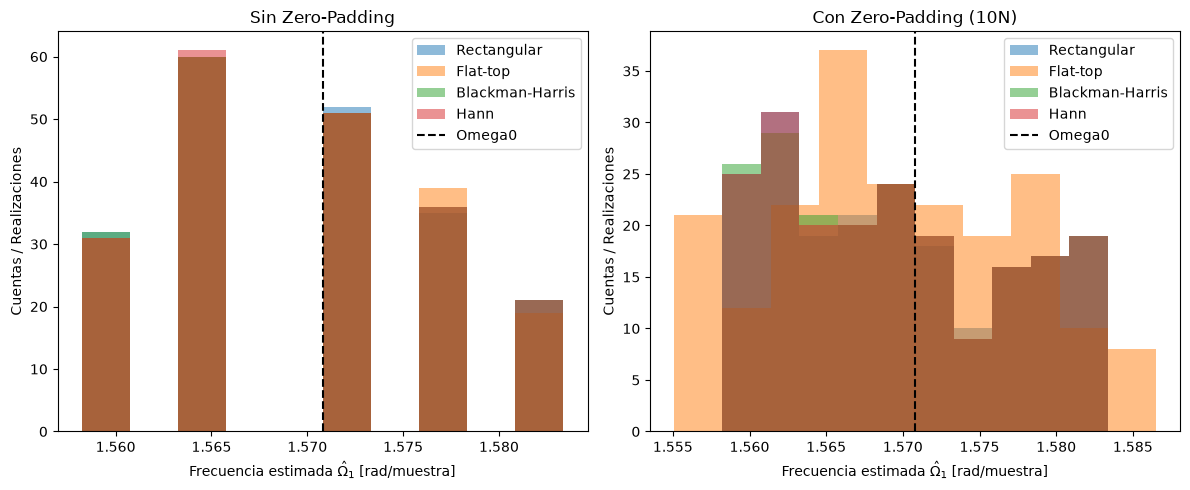

In [8]:
#%% BONUS 1: Zero-Padding en Frecuencia (10N)

N_zp = 10 * N

fxx_zp_1 = np.fft.fft(xx_vent1, n=N_zp, axis=0)
fxx_zp_2 = np.fft.fft(xx_vent2, n=N_zp, axis=0)
fxx_zp_3 = np.fft.fft(xx_vent3, n=N_zp, axis=0)
fxx_zp_4 = np.fft.fft(xx_vent4, n=N_zp, axis=0)

faxx_zp_1 = np.abs(fxx_zp_1[:N_zp//2, :]) / np.sum(vent1)
faxx_zp_2 = np.abs(fxx_zp_2[:N_zp//2, :]) / np.sum(vent2)
faxx_zp_3 = np.abs(fxx_zp_3[:N_zp//2, :]) / np.sum(vent3)
faxx_zp_4 = np.abs(fxx_zp_4[:N_zp//2, :]) / np.sum(vent4)

k_max_zp_1 = np.argmax(faxx_zp_1, axis=0)
k_max_zp_2 = np.argmax(faxx_zp_2, axis=0)
k_max_zp_3 = np.argmax(faxx_zp_3, axis=0)
k_max_zp_4 = np.argmax(faxx_zp_4, axis=0)

w_hat_zp_1 = k_max_zp_1 * (2 * np.pi / N_zp)
w_hat_zp_2 = k_max_zp_2 * (2 * np.pi / N_zp)
w_hat_zp_3 = k_max_zp_3 * (2 * np.pi / N_zp)
w_hat_zp_4 = k_max_zp_4 * (2 * np.pi / N_zp)


#%% Comparación sin y con Zero-Padding

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Sin Zero-Padding

ax[0].hist(w_hat1, alpha=0.5, label='Rectangular')
ax[0].hist(w_hat2, alpha=0.5, label='Flat-top')
ax[0].hist(w_hat3, alpha=0.5, label='Blackman-Harris')
ax[0].hist(w_hat4, alpha=0.5, label='Hann')

ax[0].axvline(
    omega,
    color='k',
    linestyle='--',
    label='Omega0'
)

ax[0].set_title('Sin Zero-Padding')
ax[0].set_xlabel('Frecuencia estimada $\\hat{\\Omega}_1$ [rad/muestra]')
ax[0].set_ylabel('Cuentas / Realizaciones')
ax[0].legend()


# Con Zero-Padding

ax[1].hist(w_hat_zp_1, alpha=0.5, label='Rectangular')
ax[1].hist(w_hat_zp_2, alpha=0.5, label='Flat-top')
ax[1].hist(w_hat_zp_3, alpha=0.5, label='Blackman-Harris')
ax[1].hist(w_hat_zp_4, alpha=0.5, label='Hann')

ax[1].axvline(
    omega,
    color='k',
    linestyle='--',
    label='Omega0'
)

ax[1].set_title('Con Zero-Padding (10N)')
ax[1].set_xlabel('Frecuencia estimada $\\hat{\\Omega}_1$ [rad/muestra]')
ax[1].set_ylabel('Cuentas / Realizaciones')
ax[1].legend()

plt.tight_layout()
plt.show()

**Figura 3.** Efecto del Zero-Padding sobre la estimación de frecuencia ($\hat{\Omega}_1$). **(Izquierda)** Histograma de la frecuencia estimada sin Zero-Padding ($N = 1000$). **(Derecha)** Histograma con Zero-Padding por un factor de 10 ($N_{zp} = 10000$), donde la grilla frecuencial más densa permite obtener estimaciones más cercanas al máximo espectral generando una distribución más continua alrededor de la frecuencia de referencia $\Omega_0 = \pi/2$ rad/muestra.


En la **Figura 3** podemos observar el efecto de aplicar **Zero-Padding (10N)** sobre la estimación de frecuencia ($\hat{\Omega}_1$).

En el **histograma sin Zero-Padding** (izquierda, $N = 1000$), la estimación realizada mediante la búsqueda de pico ($argmax$) se encuentra limitada por la resolución de la DFT, dada por $\Delta\Omega = 2\pi/1000$. Como la grilla de frecuencias no tiene tantos valores discretos, genera un **mayor error de cuantización** en la frecuencia estimada.

En el **histograma con Zero-Padding** (derecha, $N_{zp} = 10000$), se evalúa la DFT en una grilla de frecuencias con **10 veces más valores**, con $\Delta\Omega_{zp} = \Delta\Omega/10$. Aunque esto no aumenta la resolución espectral, sí permite localizar el máximo con mayor precisión, disminuyendo el **error de cuantización** debido a la grilla de la DFT.

Como resultado, las estimaciones se distribuyen en una mayor cantidad de frecuencias posibles y se encuentran más centradas alrededor de la frecuencia de referencia $\Omega_0 = \pi/2$ rad/muestra. Esto muestra que el **Zero-Padding mejora la precisión de la estimación de frecuencia realizada mediante argmax**, aunque no agrega información nueva a la señal ni aumenta la resolución espectral real.


**🤯 Proponga estimadores alternativos para frecuencia y amplitud de la senoidal y repita el experimento.**

Como alternativa al estimador tradicional basado en `argmax`, se utilizará un **estimador por interpolación parabólica**. Este método utiliza el bin donde se encuentra el máximo de la DFT y sus dos vecinos para aproximar la forma del pico mediante una parábola. A partir del vértice de esta parábola, se puede estimar con mayor precisión la posición del máximo entre los bines de la DFT. De esta manera, se busca mejorar la estimación tanto de la **frecuencia** como de la **amplitud**, reduciendo el efecto de la cuantización de la grilla y de la pérdida de amplitud producida por la desintonía de la frecuencia.


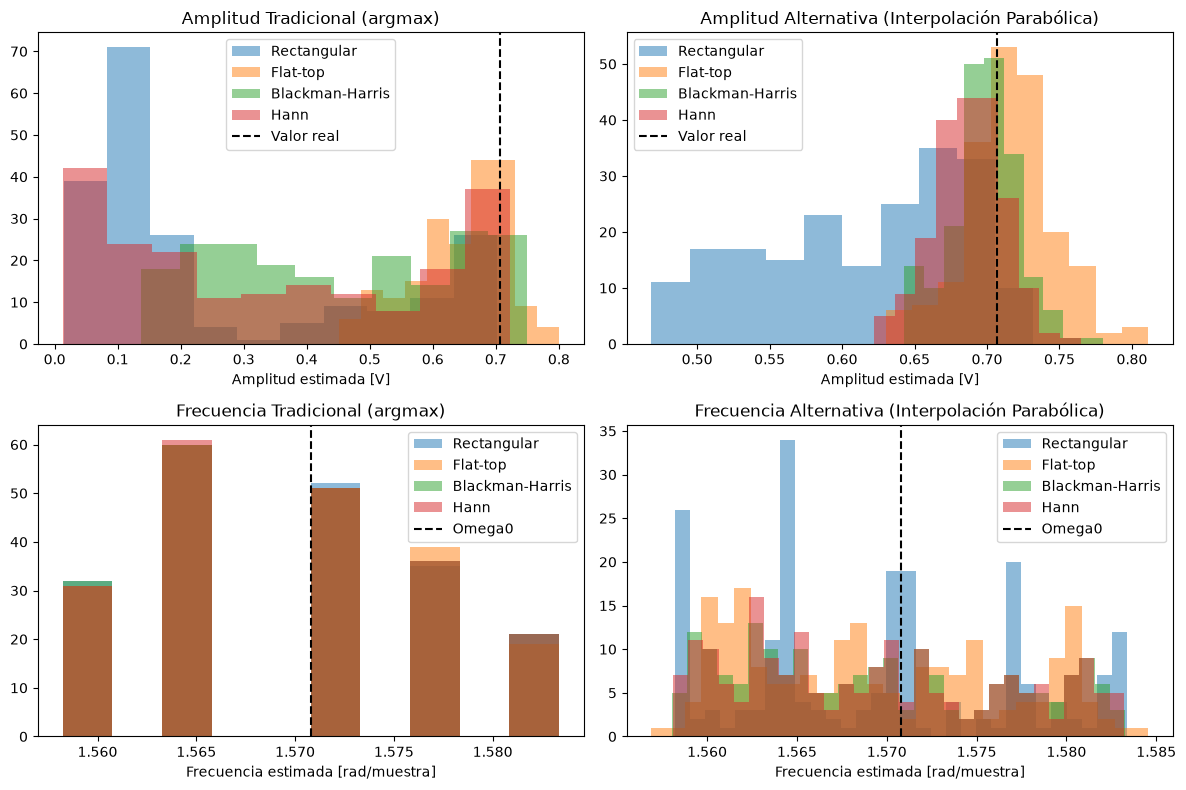

In [9]:
#%% BONUS 2: Estimadores Alternativos (Interpolación Parabólica)

def estimadores_alternativos(faxx, k_max, N):
    
    cols = np.arange(faxx.shape[1])
    
    # Amplitudes del pico y sus dos vecinos inmediatos
    y0 = faxx[k_max, cols]
    ym1 = faxx[k_max - 1, cols]
    yp1 = faxx[k_max + 1, cols]
    
    # Denominador de la parábola
    den = 2 * y0 - ym1 - yp1
    
    # Desplazamiento fraccionario dentro del bin
    delta = 0.5 * (yp1 - ym1) / den
    
    # Estimadores corregidos
    w_hat_alt = (k_max + delta) * (2 * np.pi / N)
    a_hat_alt = y0 + (1 / 8) * ((yp1 - ym1)**2) / den
    
    return w_hat_alt, a_hat_alt


# Aplicamos a las 4 ventanas
w_alt_1, a_alt_1 = estimadores_alternativos(faxx, k_max1, N)
w_alt_2, a_alt_2 = estimadores_alternativos(faxx_vent2, k_max2, N)
w_alt_3, a_alt_3 = estimadores_alternativos(faxx_vent3, k_max3, N)
w_alt_4, a_alt_4 = estimadores_alternativos(faxx_vent4, k_max4, N)


#%% Graficado Comparativo: Tradicional (Pico) vs Alternativo (Parábola)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))


# Amplitud - Tradicional
ax[0, 0].hist(a1, alpha=0.5, label='Rectangular')
ax[0, 0].hist(a1_vent2, alpha=0.5, label='Flat-top')
ax[0, 0].hist(a1_vent3, alpha=0.5, label='Blackman-Harris')
ax[0, 0].hist(a1_vent4, alpha=0.5, label='Hann')

ax[0, 0].axvline(
    a0 / 2,
    color='k',
    linestyle='--',
    label='Valor real'
)

ax[0, 0].set_title('Amplitud Tradicional (argmax)')
ax[0, 0].set_xlabel('Amplitud estimada [V]')
ax[0, 0].legend()


# Amplitud - Alternativo
ax[0, 1].hist(a_alt_1, alpha=0.5, label='Rectangular')
ax[0, 1].hist(a_alt_2, alpha=0.5, label='Flat-top')
ax[0, 1].hist(a_alt_3, alpha=0.5, label='Blackman-Harris')
ax[0, 1].hist(a_alt_4, alpha=0.5, label='Hann')

ax[0, 1].axvline(
    a0 / 2,
    color='k',
    linestyle='--',
    label='Valor real'
)

ax[0, 1].set_title('Amplitud Alternativa (Interpolación Parabólica)')
ax[0, 1].set_xlabel('Amplitud estimada [V]')
ax[0, 1].legend()


# Frecuencia - Tradicional
ax[1, 0].hist(w_hat1, alpha=0.5, label='Rectangular')
ax[1, 0].hist(w_hat2, alpha=0.5, label='Flat-top')
ax[1, 0].hist(w_hat3, alpha=0.5, label='Blackman-Harris')
ax[1, 0].hist(w_hat4, alpha=0.5, label='Hann')

ax[1, 0].axvline(
    omega,
    color='k',
    linestyle='--',
    label='Omega0'
)

ax[1, 0].set_title('Frecuencia Tradicional (argmax)')
ax[1, 0].set_xlabel('Frecuencia estimada [rad/muestra]')
ax[1, 0].legend()


# Frecuencia - Alternativo
ax[1, 1].hist(w_alt_1, bins=30, alpha=0.5, label='Rectangular')
ax[1, 1].hist(w_alt_2, bins=30, alpha=0.5, label='Flat-top')
ax[1, 1].hist(w_alt_3, bins=30, alpha=0.5, label='Blackman-Harris')
ax[1, 1].hist(w_alt_4, bins=30, alpha=0.5, label='Hann')

ax[1, 1].axvline(
    omega,
    color='k',
    linestyle='--',
    label='Omega0'
)

ax[1, 1].set_title('Frecuencia Alternativa (Interpolación Parabólica)')
ax[1, 1].set_xlabel('Frecuencia estimada [rad/muestra]')
ax[1, 1].legend()


plt.tight_layout()
plt.show()


**Figura 4.** Comparación entre el estimador tradicional basado en argmax y el estimador alternativo mediante interpolación parabólica para las ventanas Rectangular, Flat-top, Blackman-Harris y Hann. Se muestran las estimaciones de amplitud (arriba) y frecuencia (abajo), permitiendo observar el efecto de la interpolación sobre la precisión de ambos estimadores.


En la **Figura 4** podemos observar el comportamiento del estimador tradicional basado en `argmax` y del estimador alternativo mediante **interpolación parabólica**, utilizando el bin de mayor amplitud y sus dos bines vecinos.

En la **estimación de amplitud ($\hat{a}_1$)**, podemos observar que las ventanas **Rectangular, Hann y Blackman-Harris** presentan un sesgo negativo con el estimador tradicional. Esto se debe a la pérdida de amplitud producida cuando la frecuencia de la señal no coincide exactamente con un bin de la DFT (*scalloping loss*). Al utilizar la interpolación parabólica, se tiene en cuenta la forma del pico y sus vecinos, permitiendo estimar una amplitud más cercana al máximo del lóbulo principal. Por esto, las distribuciones de estas ventanas se acercan al valor teórico $\sqrt{2}/2 \approx 0.7071$ V.

En la **estimación de frecuencia ($\hat{\Omega}_1$)**, el estimador tradicional queda limitado a los valores de la grilla de la DFT, por lo que las estimaciones pueden saltar entre bines cercanos. En cambio, la interpolación parabólica calcula un desplazamiento fraccionario $\delta$ respecto del bin de mayor amplitud. De esta forma, la frecuencia estimada puede tomar valores entre dos bines, reduciendo el efecto de la cuantización producido por la grilla de la DFT.

Como resultado, las estimaciones de frecuencia obtenidas mediante interpolación parabólica se distribuyen en una mayor cantidad de valores y se encuentran más centradas alrededor de la frecuencia de referencia $\Omega_0 = \pi/2$ rad/muestra. Esto permite obtener una estimación más precisa de la frecuencia sin modificar el número de puntos utilizados en la DFT.


## Conclusión

En este trabajo práctico se analizó el comportamiento de cuatro funciones de ventaneo (**Rectangular, Flat-top, Blackman-Harris y Hann**) en la estimación de amplitud ($\hat{a}_1$) y frecuencia ($\hat{\Omega}_1$) de una señal senoidal bajo condiciones de desintonía aleatoria ($f_r \sim U(-2,2)$ bines) y ruido gaussiano, para niveles de **SNR = 3 dB y 10 dB**.

A partir de los resultados obtenidos mediante las simulaciones, se pueden extraer las siguientes conclusiones:

1. **Estimación de amplitud y efecto de la desintonía:**
   El estimador tradicional basado en la búsqueda del pico máximo de la DFT (`argmax`) presenta un **sesgo negativo** en las ventanas **Rectangular, Hann y Blackman-Harris**. La ventana Rectangular presenta el mayor sesgo negativo, de aproximadamente $-0.424$ V. Esto se debe a la pérdida de amplitud producida cuando la frecuencia de la señal no coincide exactamente con un bin de la DFT (*scalloping loss*). La ventana **Flat-top** presenta el sesgo más cercano a cero, de aproximadamente $-0.051$ V, debido a la forma plana de su lóbulo principal, que reduce la variación de la amplitud frente a la desintonía.

2. **Efecto de la SNR sobre la varianza:**
   Para las ventanas **Rectangular, Hann y Blackman-Harris**, la varianza de la estimación de amplitud se mantiene prácticamente igual al pasar de **SNR = 3 dB** a **SNR = 10 dB**. Esto se debe a que la variación producida por la desintonía aleatoria es mucho mayor que la producida por el ruido. En cambio, en la ventana **Flat-top**, la influencia de la desintonía es menor y el efecto del ruido tiene una mayor influencia sobre la varianza, por lo que se observa una disminución al aumentar la SNR.

3. **Estimación de frecuencia y cuantización de la DFT:**
   El estimador tradicional de frecuencia presenta un **sesgo muy cercano a cero** para las cuatro ventanas. Esto se debe principalmente a que la desintonía aleatoria $f_r$ está distribuida simétricamente alrededor de la frecuencia de referencia. Sin embargo, la estimación de frecuencia queda limitada a los valores de la grilla de la DFT, con un paso de $\Delta\Omega = 2\pi/N$. Por este motivo, las estimaciones pueden saltar entre bines cercanos. Las cuatro ventanas presentan valores de varianza prácticamente iguales y el cambio de SNR no produce una diferencia apreciable.

4. **Zero-Padding e interpolación parabólica:**
   La aplicación de **Zero-Padding (10N)** permite evaluar la DFT sobre una grilla de frecuencias diez veces más grande, reduciendo el error de cuantización de la estimación. Si bien esto no aumenta la resolución espectral real, permite localizar el máximo con mayor precisión.
   Por otro lado, la **interpolación parabólica** utiliza el bin de mayor amplitud y sus dos vecinos para estimar la posición del máximo entre los bines de la DFT. Esto permite reducir el efecto de la cuantización en la estimación de frecuencia y obtener una estimación de amplitud más cercana al máximo del lóbulo principal. De esta manera, se puede mejorar la estimación sin necesidad de aumentar el número de puntos de la DFT.

